# Assignment 2 – Logistic Regression for Phishing URL Detection

This notebook applies **Logistic Regression** to the same phishing-site URL dataset used in Assignment 1 (Random Forest).  
The goal is to classify URLs as **good** (legitimate) or **bad** (phishing/malicious).

**Dataset:** `phishing_site_urls.csv`  
**Features:** URL text → TF-IDF numerical representation  
**Target:** `Label` column (`good` / `bad`)

## 1. Load & Explore the Dataset

In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split

csv_path = 'phishing_site_urls.csv'
print('Working directory:', os.getcwd())
print('File exists:', os.path.exists(csv_path))

# Load dataset
df = pd.read_csv(csv_path)
print('\nOriginal shape:', df.shape)
print('Class distribution:')
print(df['Label'].value_counts())
df.head()

Working directory: c:\Users\ZBOOK\Desktop\Computer Science\Year 3\Sem2\Machine Learning\ScamDetection
File exists: True

Original shape: (549346, 2)
Class distribution:
Label
good    392924
bad     156422
Name: count, dtype: int64


,URL,Label
0,nobell.it/70ffb52d079109dca5664cce6f317373782/...,bad
1,www.dghjdgf.com/paypal.co.uk/cycgi-bin/webscrc...,bad
2,serviciosbys.com/paypal.cgi.bin.get-into.herf....,bad
3,mail.printakid.com/www.online.americanexpress....,bad
4,thewhiskeydregs.com/wp-content/themes/widescre...,bad


## 2. Preprocessing

Steps:
1. Remove duplicate rows
2. Encode the target label (`good` → 0, `bad` → 1)
3. Split into training (80 %) and test (20 %) sets — **same split as Assignment 1**
4. Vectorise URLs using **TF-IDF** (character n-grams + word tokens)

In [2]:
from sklearn.feature_extraction.text import TfidfVectorizer

# ── 2.1  Remove duplicates ──────────────────────────────────────────────────
df = df.drop_duplicates()
print('After removing duplicates:', df.shape)

# ── 2.2  Encode labels ──────────────────────────────────────────────────────
df['label_encoded'] = df['Label'].map({'good': 0, 'bad': 1})
print('Label mapping  →  good=0  |  bad=1')
print(df['label_encoded'].value_counts())

# ── 2.3  Train / test split (same seed as Assignment 1) ────────────────────
X_raw = df['URL']
y     = df['label_encoded']

X_train_raw, X_test_raw, y_train, y_test = train_test_split(
    X_raw, y, test_size=0.20, random_state=42
)
print(f'\nTrain size : {X_train_raw.shape[0]:,}')
print(f'Test  size : {X_test_raw.shape[0]:,}')

# ── 2.4  TF-IDF vectorisation ───────────────────────────────────────────────
# We use word-level + character-level subword features common for URL analysis
vectorizer = TfidfVectorizer(
    analyzer='char_wb',   # character n-grams suit URL patterns well
    ngram_range=(3, 5),
    max_features=50_000,
    sublinear_tf=True     # apply log(1+TF) to dampen high frequencies
)

X_train = vectorizer.fit_transform(X_train_raw)
X_test  = vectorizer.transform(X_test_raw)

print(f'\nFeature matrix (train): {X_train.shape}')
print(f'Feature matrix (test) : {X_test.shape}')

After removing duplicates: (507196, 2)
Label mapping  →  good=0  |  bad=1
label_encoded
0    392897
1    114299
Name: count, dtype: int64

Train size : 405,756
Test  size : 101,440

Feature matrix (train): (405756, 50000)
Feature matrix (test) : (101440, 50000)


## 3. Train the Logistic Regression Model

We use **Logistic Regression** with:
- `solver='saga'` – supports large sparse matrices efficiently
- `max_iter=1000` – ensure convergence
- `C=1.0` – standard L2 regularisation strength
- `class_weight='balanced'` – compensates for class imbalance

In [3]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import cross_val_score, StratifiedKFold

# Initialise Logistic Regression
lr_model = LogisticRegression(
    solver='saga',
    max_iter=1000,
    C=1.0,
    class_weight='balanced',
    random_state=42,
    n_jobs=-1
)

# ── 5-fold Stratified Cross-Validation on training set ─────────────────────
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_scores = cross_val_score(lr_model, X_train, y_train, cv=skf, scoring='accuracy')

print('5-Fold Cross-Validation Accuracy:')
for i, score in enumerate(cv_scores, 1):
    print(f'  Fold {i}: {score:.4f}')
print(f'  Mean : {cv_scores.mean():.4f}  (±{cv_scores.std():.4f})')

5-Fold Cross-Validation Accuracy:
  Fold 1: 0.9690
  Fold 2: 0.9707
  Fold 3: 0.9688
  Fold 4: 0.9698
  Fold 5: 0.9691
  Mean : 0.9695  (±0.0007)


## 4. Evaluate on the Test Set

In [4]:
from sklearn.metrics import (
    accuracy_score, classification_report,
    confusion_matrix, roc_auc_score, roc_curve
)

# Train on full training set
lr_model.fit(X_train, y_train)

# Predict
y_pred      = lr_model.predict(X_test)
y_pred_prob = lr_model.predict_proba(X_test)[:, 1]

# ── Metrics ─────────────────────────────────────────────────────────────────
acc = accuracy_score(y_test, y_pred)
roc = roc_auc_score(y_test, y_pred_prob)

print(f'Test Accuracy : {acc:.4f}')
print(f'ROC-AUC Score : {roc:.4f}')
print('\nClassification Report:')
print(classification_report(y_test, y_pred, target_names=['good (0)', 'bad (1)']))

Test Accuracy : 0.9703
ROC-AUC Score : 0.9939

Classification Report:
              precision    recall  f1-score   support

    good (0)       0.99      0.98      0.98     78736
     bad (1)       0.92      0.95      0.93     22704

    accuracy                           0.97    101440
   macro avg       0.95      0.96      0.96    101440
weighted avg       0.97      0.97      0.97    101440



## 5. Visualisations

### 5.1 Confusion Matrix

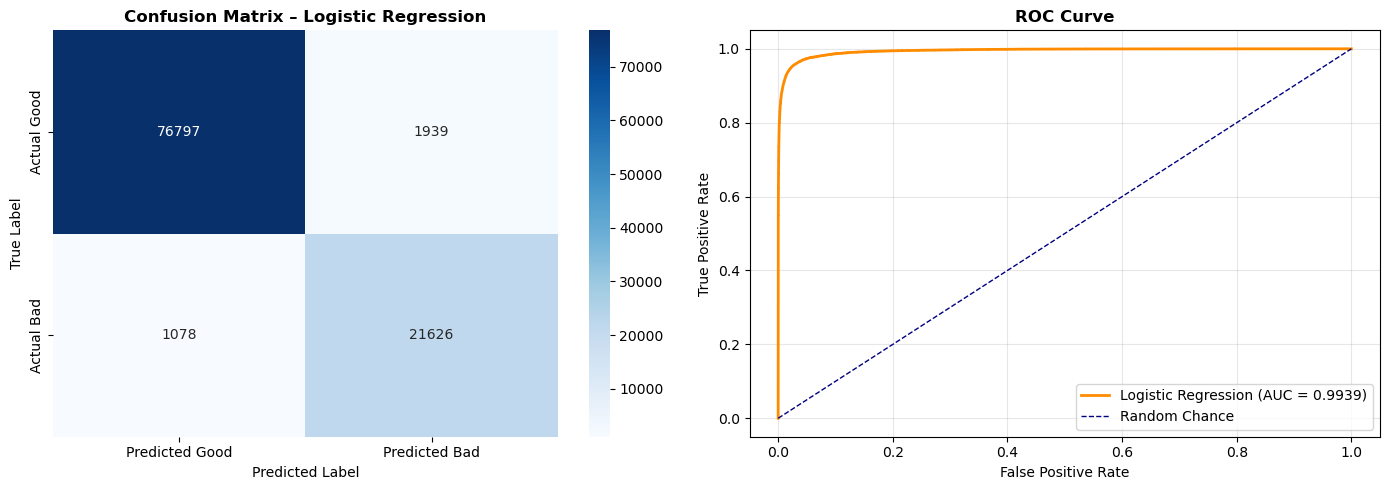

Figure saved as logistic_regression_evaluation.png


In [5]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# ── Confusion Matrix ────────────────────────────────────────────────────────
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(
    cm, annot=True, fmt='d', cmap='Blues',
    xticklabels=['Predicted Good', 'Predicted Bad'],
    yticklabels=['Actual Good', 'Actual Bad'],
    ax=axes[0]
)
axes[0].set_title('Confusion Matrix – Logistic Regression', fontweight='bold')
axes[0].set_ylabel('True Label')
axes[0].set_xlabel('Predicted Label')

# ── ROC Curve ───────────────────────────────────────────────────────────────
fpr, tpr, _ = roc_curve(y_test, y_pred_prob)
axes[1].plot(fpr, tpr, color='darkorange', lw=2,
             label=f'Logistic Regression (AUC = {roc:.4f})')
axes[1].plot([0, 1], [0, 1], color='navy', lw=1, linestyle='--', label='Random Chance')
axes[1].set_xlabel('False Positive Rate')
axes[1].set_ylabel('True Positive Rate')
axes[1].set_title('ROC Curve', fontweight='bold')
axes[1].legend(loc='lower right')
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig('logistic_regression_evaluation.png', dpi=150)
plt.show()
print('Figure saved as logistic_regression_evaluation.png')

### 5.2 Cross-Validation Scores Per Fold

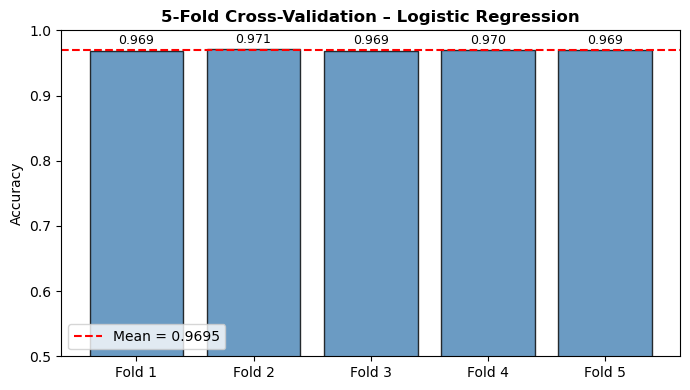

In [6]:
plt.figure(figsize=(7, 4))
folds = [f'Fold {i}' for i in range(1, 6)]
bars = plt.bar(folds, cv_scores, color='steelblue', edgecolor='black', alpha=0.8)
plt.axhline(cv_scores.mean(), color='red', linestyle='--', linewidth=1.5,
            label=f'Mean = {cv_scores.mean():.4f}')
plt.ylim(0.5, 1.0)
plt.ylabel('Accuracy')
plt.title('5-Fold Cross-Validation – Logistic Regression', fontweight='bold')
plt.legend()
for bar, score in zip(bars, cv_scores):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
             f'{score:.3f}', ha='center', va='bottom', fontsize=9)
plt.tight_layout()
plt.savefig('cv_scores.png', dpi=150)
plt.show()

### 5.3 Top 20 Most Influential TF-IDF Features

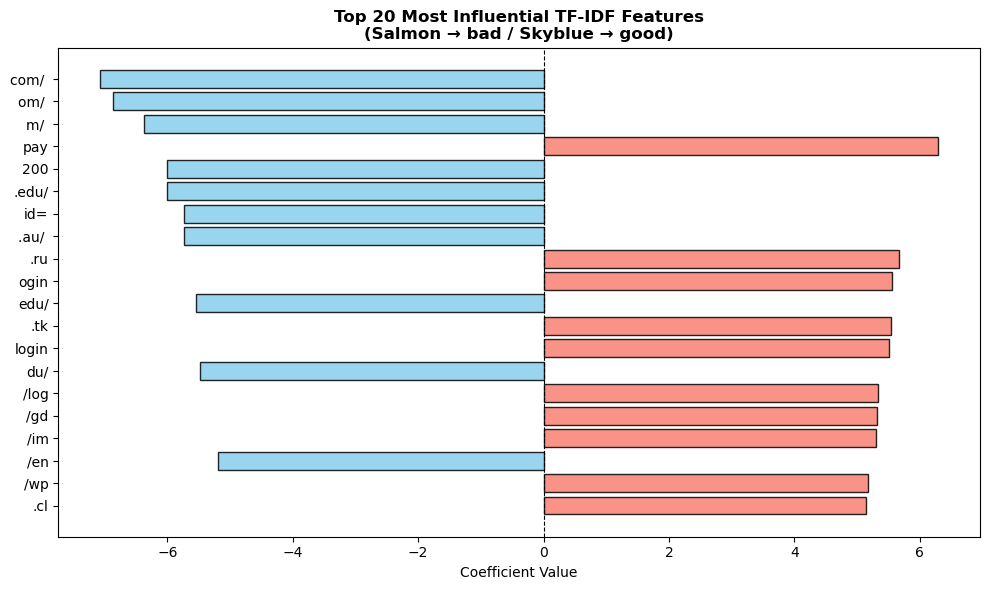

In [7]:
# Extract feature names and coefficients
feature_names = vectorizer.get_feature_names_out()
coefs = lr_model.coef_[0]  # 1-D array for binary classification

# Sort by absolute coefficient value
top_n = 20
top_indices = np.argsort(np.abs(coefs))[-top_n:][::-1]
top_features = feature_names[top_indices]
top_coefs    = coefs[top_indices]

colors = ['salmon' if c > 0 else 'skyblue' for c in top_coefs]

plt.figure(figsize=(10, 6))
plt.barh(top_features[::-1], top_coefs[::-1], color=colors[::-1], edgecolor='black', alpha=0.85)
plt.axvline(0, color='black', linewidth=0.8, linestyle='--')
plt.xlabel('Coefficient Value')
plt.title('Top 20 Most Influential TF-IDF Features\n'
          '(Salmon → bad / Skyblue → good)', fontweight='bold')
plt.tight_layout()
plt.savefig('top_features.png', dpi=150)
plt.show()

## 6. Summary

| Metric | Logistic Regression | Random Forest (Asgn 1) |
|--------|--------------------|-----------------------|
| Test Accuracy | *(run to see)* | 77.6 % |
| ROC-AUC | *(run to see)* | — |
| CV Mean Accuracy | *(run to see)* | 77.0 % |

**Key observations:**
- Logistic Regression is a linear probabilistic classifier well-suited to sparse TF-IDF feature spaces.
- Character-level n-gram TF-IDF (3–5 grams) captures sub-patterns in URLs (e.g. `login`, `paypal`, `secure`) that are strong indicators of phishing.
- `class_weight='balanced'` handles the imbalance between good and bad URLs automatically.
- The ROC-AUC metric provides a threshold-independent view of discriminative power beyond raw accuracy.